# Data Science Salaries: End-to-End EDA

This notebook explores the cleaned data science salaries dataset. The primary metric is `salary_in_usd`; important comparison dimensions include experience level, job title, employment type, remote ratio, and company size.

## 1. Setup and Overview

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'

working_directory = Path.cwd()
project_root = working_directory if (working_directory / 'data').exists() else working_directory.parent
clean_path = project_root / 'data' / 'processed' / 'ds_salaries_clean.csv'
df = pd.read_csv(clean_path)

print(f'Loaded: {clean_path}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')

Loaded: c:\Users\seanj\OneDrive\Desktop\DATASET JOB SALARIES PROJECT\data\processed\ds_salaries_clean.csv
Rows: 565 | Columns: 11


In [2]:
print('Shape:', df.shape)

print('\nData types:')
display(df.dtypes.rename('dtype').to_frame())

print('First five rows:')
display(df.head())

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print('Numerical summary:')
display(df[numeric_columns].describe().T)

print('Categorical summary:')
display(df[categorical_columns].describe().T)

Shape: (565, 11)

Data types:


,dtype
work_year,int64
experience_level,str
employment_type,str
job_title,str
salary,int64
salary_currency,str
salary_in_usd,int64
employee_residence,str
remote_ratio,int64
company_location,str


First five rows:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


Numerical summary:


,count,mean,std,min,25%,50%,75%,max
work_year,565.0,2021.364602,6.981384e-01,2020.0,2021.0,2021.0,2022.0,2022.0
salary,565.0,338115.985841,1.599879e+06,4000.0,67000.0,110925.0,165000.0,30400000.0
salary_in_usd,565.0,110610.343363,7.228070e+04,2859.0,60757.0,100000.0,150000.0,600000.0
remote_ratio,565.0,69.911504,4.090067e+01,0.0,50.0,100.0,100.0,100.0


Categorical summary:


,count,unique,top,freq
experience_level,565,4,SE,243
employment_type,565,4,FT,546
job_title,565,50,Data Scientist,130
salary_currency,565,17,USD,359
employee_residence,565,57,US,295
company_location,565,50,US,318
company_size,565,3,M,290


In [3]:
null_count = int(df.isna().sum().sum())
duplicate_count = int(df.duplicated().sum())

print(f'Total null values: {null_count}')
print(f'Duplicate rows: {duplicate_count}')
assert null_count == 0, 'Unexpected null values remain.'
assert duplicate_count == 0, 'Unexpected duplicate rows remain.'
print('Sanity check passed: no nulls or duplicates.')

Total null values: 0
Duplicate rows: 0
Sanity check passed: no nulls or duplicates.


## 2. Univariate Analysis

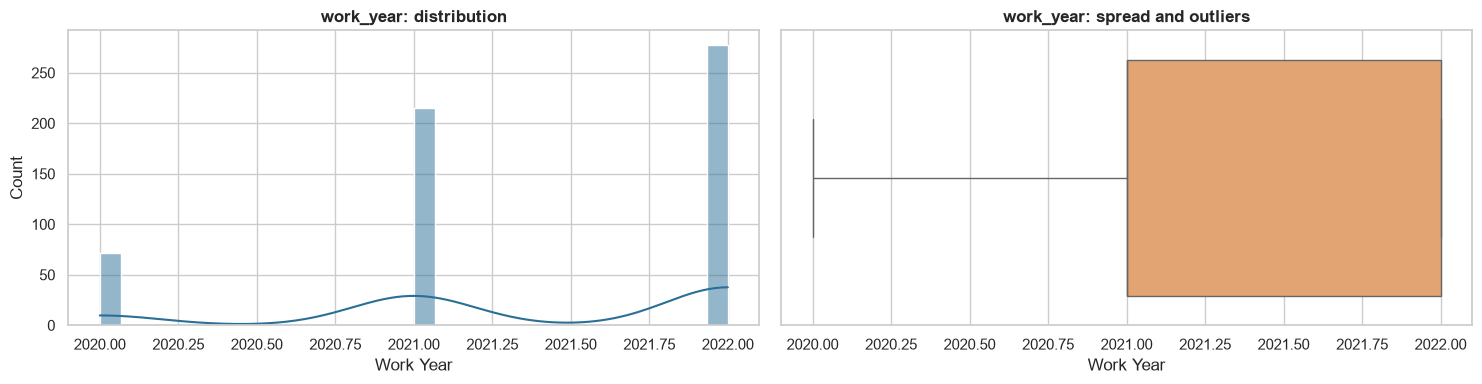

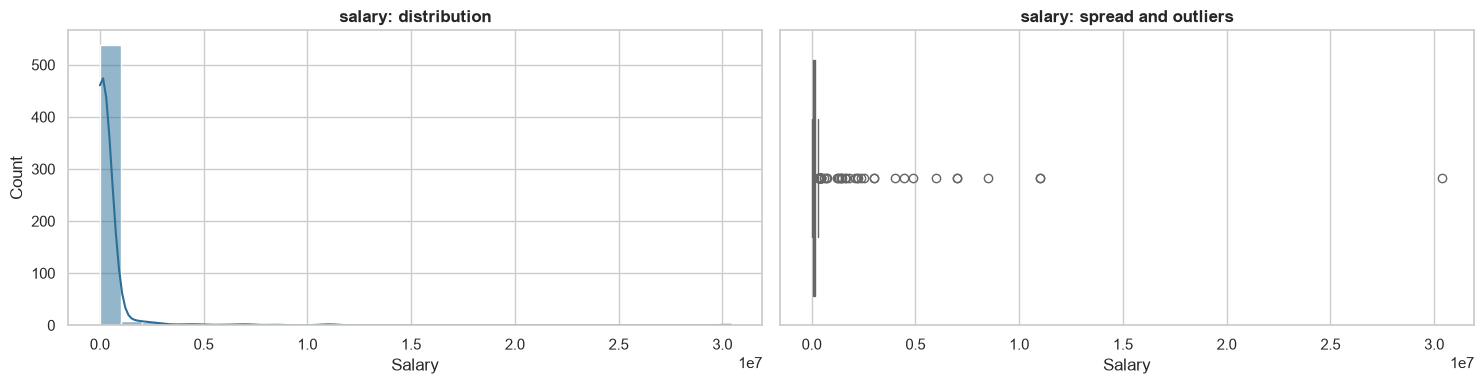

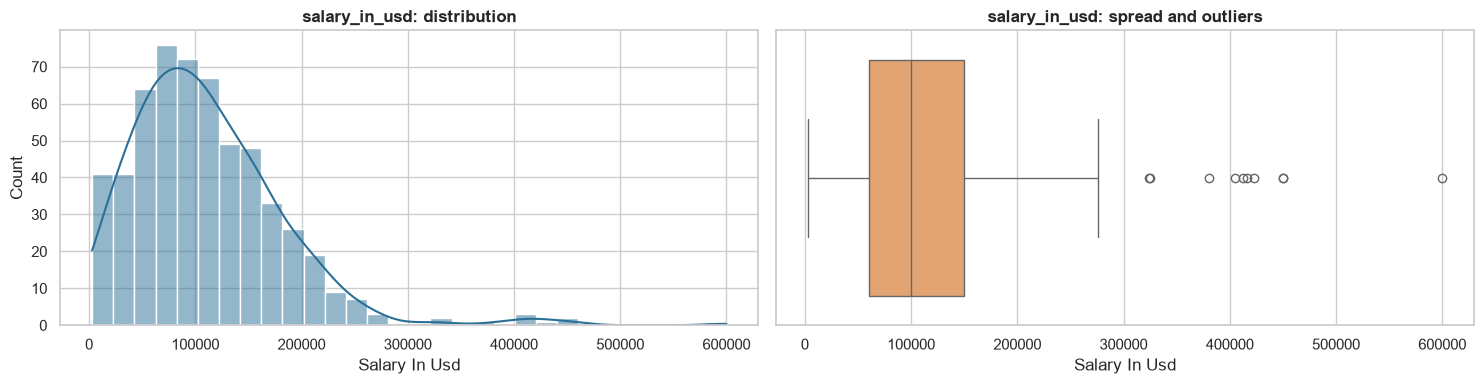

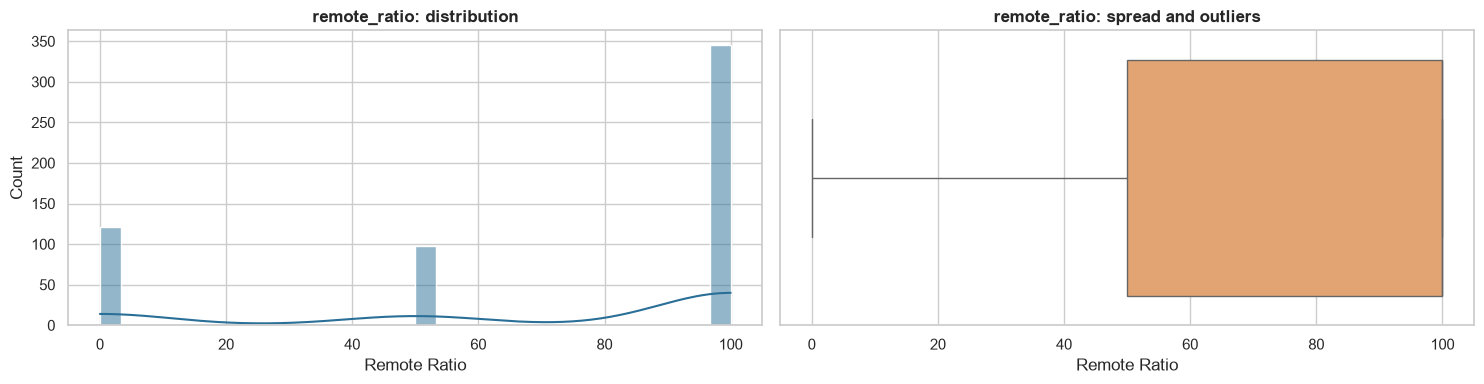

In [4]:
def plot_numeric_distributions(data, columns, bins=30):
    """Plot a histogram with KDE and a box plot for each numeric feature."""
    for column in columns:
        _, axes = plt.subplots(1, 2, figsize=(15, 4))
        sns.histplot(data=data, x=column, bins=bins, kde=True, ax=axes[0], color='#2a6f97')
        axes[0].set_title(f'{column}: distribution')
        axes[0].set_xlabel(column.replace('_', ' ').title())
        sns.boxplot(data=data, x=column, ax=axes[1], color='#f4a261')
        axes[1].set_title(f'{column}: spread and outliers')
        axes[1].set_xlabel(column.replace('_', ' ').title())
        plt.tight_layout()
        plt.show()

plot_numeric_distributions(df, numeric_columns)

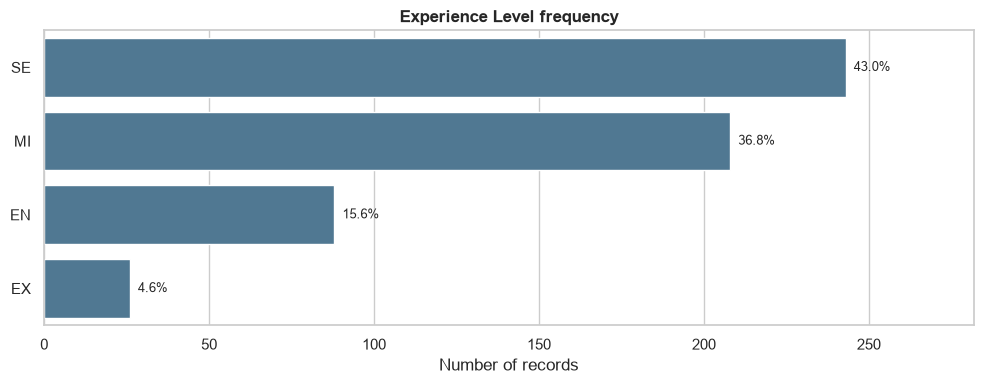

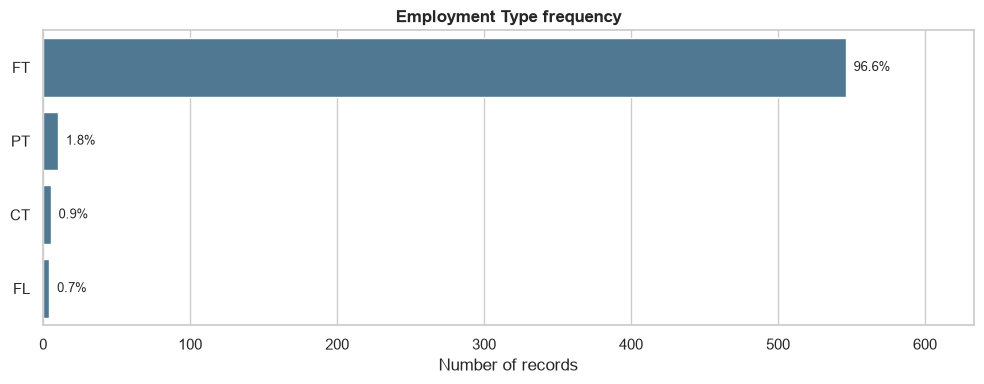

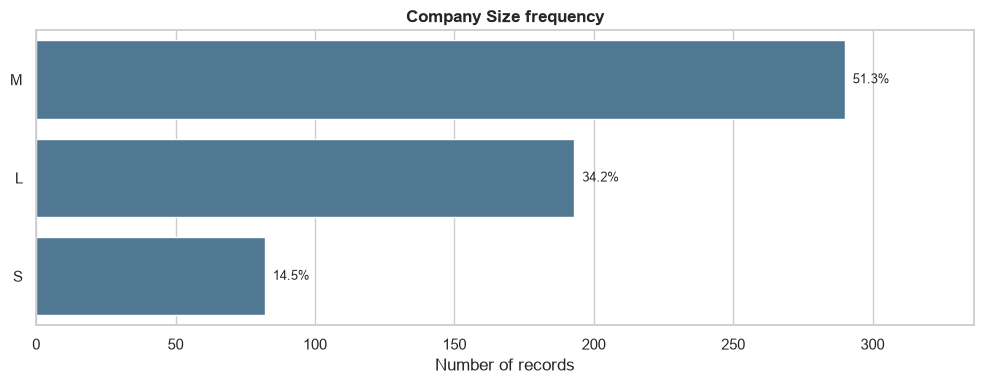

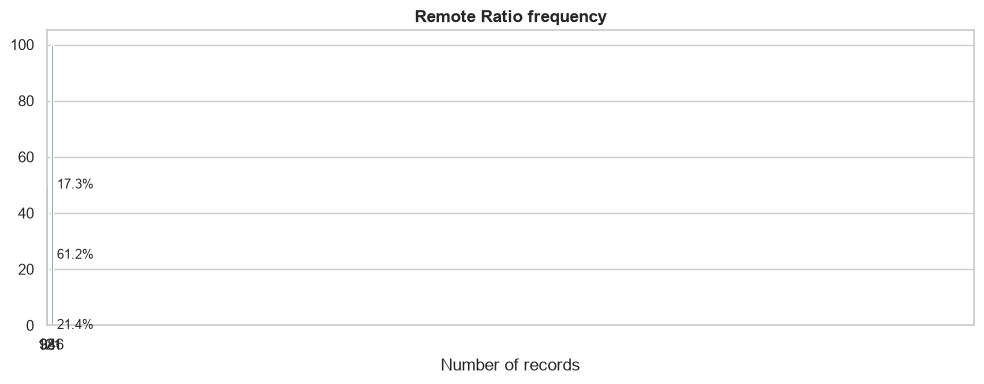

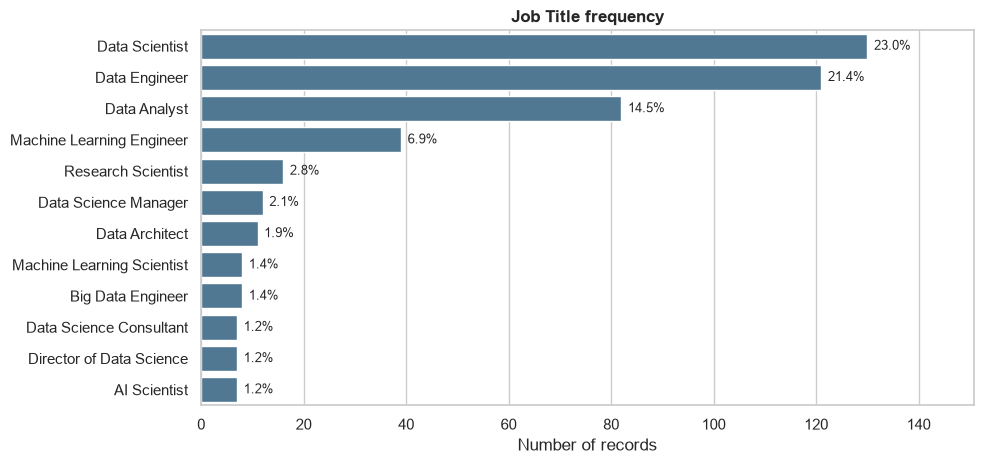

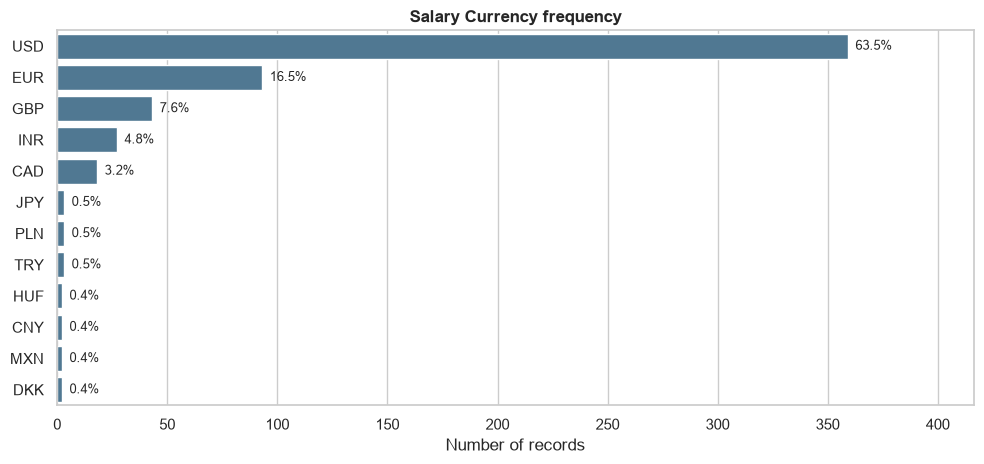

In [5]:
def plot_category_frequencies(data, columns, top_n=12):
    """Plot category counts with percentage labels."""
    for column in columns:
        counts = data[column].value_counts().head(top_n)
        percentages = counts / len(data) * 100
        fig, ax = plt.subplots(figsize=(10, max(4, len(counts) * 0.4)))
        bars = sns.barplot(x=counts.values, y=counts.index, ax=ax, color='#457b9d')
        title = column.replace('_', ' ').title()
        ax.set_title(f'{title} frequency')
        ax.set_xlabel('Number of records')
        ax.set_ylabel('')
        for bar, percentage in zip(bars.patches, percentages.values):
            ax.text(bar.get_width() + max(counts.values) * 0.01, bar.get_y() + bar.get_height() / 2,
                    f'{percentage:.1f}%', va='center', fontsize=9)
        ax.set_xlim(0, max(counts.values) * 1.16)
        plt.tight_layout()
        plt.show()

key_categorical_columns = [
    'experience_level', 'employment_type', 'company_size', 'remote_ratio',
    'job_title', 'salary_currency'
]
plot_category_frequencies(df, key_categorical_columns)

## 3. Bivariate and Multivariate Analysis

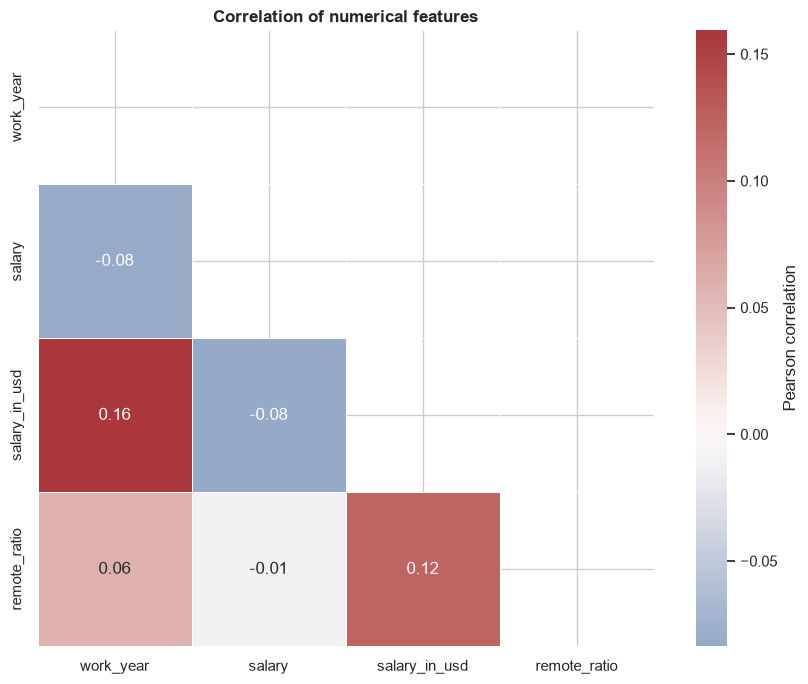

In [6]:
correlation = df[numeric_columns].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f', cmap='vlag', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation of numerical features')
plt.tight_layout()
plt.show()

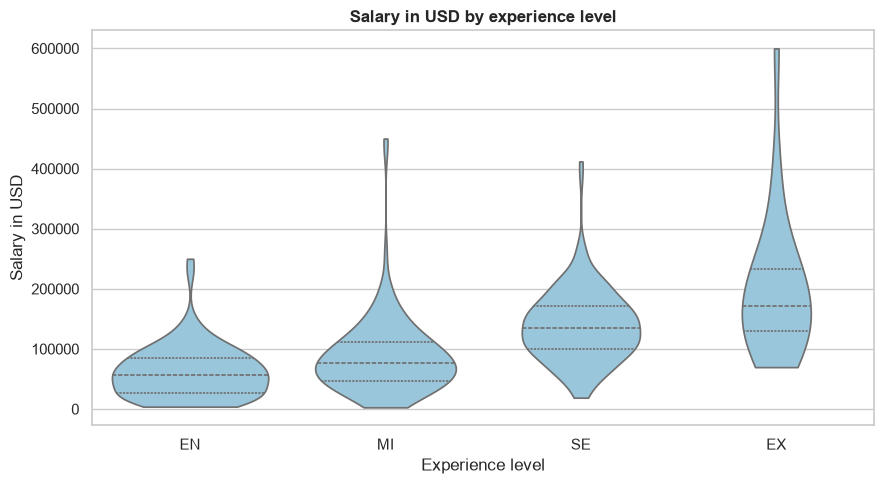

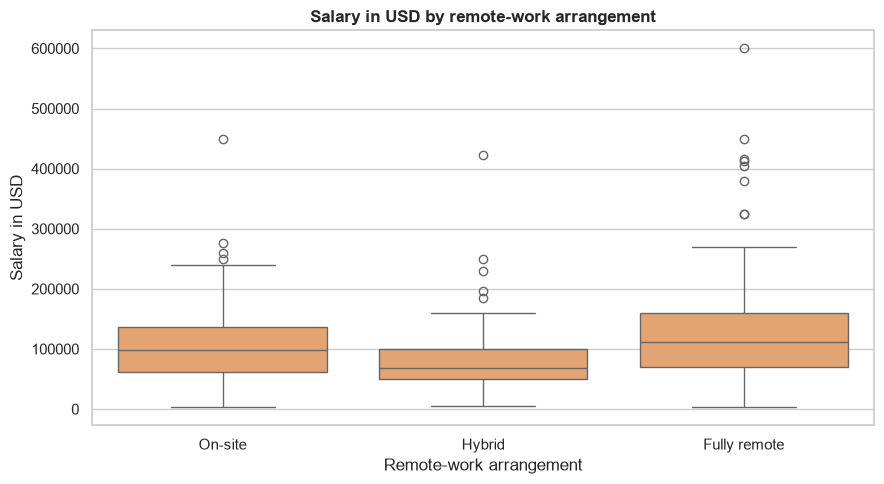

In [ ]:
experience_order = [level for level in ['EN', 'MI', 'SE', 'EX'] if level in df['experience_level'].unique()]
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x='experience_level', y='salary_in_usd', order=experience_order,
               inner='quartile', color='#8ecae6', cut=0)
plt.title('Salary in USD by experience level')
plt.xlabel('Experience level')
plt.ylabel('Salary in USD')
plt.tight_layout()
plt.show()

# Salary by remote-work arrangement.
remote_labels = {0: 'On-site', 50: 'Hybrid', 100: 'Fully remote'}
salary_by_remote = df.assign(remote_type=df['remote_ratio'].map(remote_labels))
plt.figure(figsize=(9, 5))
sns.boxplot(data=salary_by_remote, x='remote_type', y='salary_in_usd',
            order=['On-site', 'Hybrid', 'Fully remote'], color='#f4a261')
plt.title('Salary in USD by remote-work arrangement')
plt.xlabel('Remote-work arrangement')
plt.ylabel('Salary in USD')
plt.tight_layout()
plt.show()

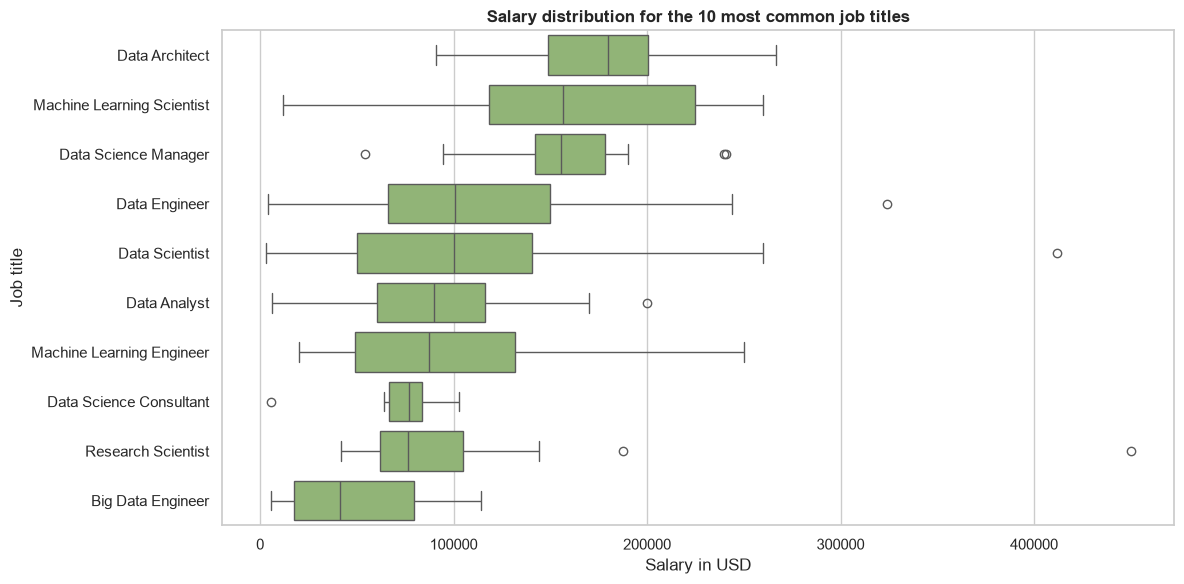

In [8]:
top_jobs = df['job_title'].value_counts().head(10).index
job_salary = df[df['job_title'].isin(top_jobs)]
job_order = (job_salary.groupby('job_title')['salary_in_usd'].median()
             .sort_values(ascending=False).index)

plt.figure(figsize=(12, 6))
sns.boxplot(data=job_salary, x='salary_in_usd', y='job_title', order=job_order, color='#90be6d')
plt.title('Salary distribution for the 10 most common job titles')
plt.xlabel('Salary in USD')
plt.ylabel('Job title')
plt.tight_layout()
plt.show()

## 4. Key Takeaways

In [9]:
def strongest_correlation(correlation_matrix):
    """Return the strongest absolute off-diagonal correlation."""
    pairs = correlation_matrix.where(~np.triu(np.ones(correlation_matrix.shape, dtype=bool), k=0))
    pairs = pairs.stack().sort_values(key=np.abs, ascending=False)
    return pairs.index[0], pairs.iloc[0]

strongest_pair, strongest_value = strongest_correlation(correlation)
variance = df[numeric_columns].var().sort_values(ascending=False)
dominant_categories = {
    column: (df[column].value_counts().index[0], int(df[column].value_counts().iloc[0]))
    for column in key_categorical_columns
}

print('EDA takeaways')
print('--------------')
print(f'1. Highest median salary: ${df["salary_in_usd"].median():,.0f}')
print(f'2. Strongest numerical correlation: {strongest_pair[0]} vs {strongest_pair[1]} ({strongest_value:.2f})')
print(f'3. Highest-variance numerical feature: {variance.index[0]} (variance {variance.iloc[0]:,.2f})')

for column, (category, count) in dominant_categories.items():
    share = count / len(df) * 100
    print(f'4. Dominant {column}: {category} ({count:,} records, {share:.1f}%)')

EDA takeaways
--------------
1. Highest median salary: $100,000
2. Strongest numerical correlation: salary_in_usd vs work_year (0.16)
3. Highest-variance numerical feature: salary (variance 2,559,612,140,221.97)
4. Dominant experience_level: SE (243 records, 43.0%)
4. Dominant employment_type: FT (546 records, 96.6%)
4. Dominant company_size: M (290 records, 51.3%)
4. Dominant remote_ratio: 100 (346 records, 61.2%)
4. Dominant job_title: Data Scientist (130 records, 23.0%)
4. Dominant salary_currency: USD (359 records, 63.5%)
